# Chapter 4 — Fundamental IoT Concepts and Paradigms

**Companion practice notebook for _Fundamentals of the Internet of Things_**

This notebook is intentionally introductory. It does not require hardware, cloud accounts, external datasets, or specialised libraries. The goal is to turn four abstract ideas from the chapter into small, inspectable experiments:

1. **Context awareness** — a smart room changes its behaviour when occupancy and daylight change.
2. **Cyber-physical systems (CPS)** — delayed information changes the behaviour of a feedback loop.
3. **Internet of Services (IoS)** — service composition affects end-to-end reliability and latency.
4. **Ambient intelligence (AmI)** — an adaptive environment must balance human preferences with resource use.

All numerical values are pedagogical. They are not measurements from a named building, controller, cloud platform, or commercial IoT product.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
print("Ready.")

Ready.


## Exercise 4.1 — Context-aware smart room: fixed schedule vs contextual policy

### Question
Does a system that knows **occupancy** and **daylight** behave differently from one that follows only a fixed clock schedule?

We use a 15-minute synthetic weekday. A fixed policy turns the lights on from 08:00 to 18:00. A context-aware policy turns them on only when the room is occupied and indoor daylight is below 300 lux. For heating, both policies use a simple setpoint schedule. The quantity reported for heating is a **setpoint–outdoor temperature-lift proxy** (°C·h), not an energy model or a standard heating-degree-day calculation.

The experiment therefore isolates the *information effect*: decisions become conditional on context rather than on time alone.


In [2]:
step_h = 0.25
hour = np.arange(0, 24, step_h)

occupied = ((hour >= 8.5) & (hour < 12.0)) | ((hour >= 13.0) & (hour < 17.5))
daylight = np.maximum(0, 520 * np.sin(np.pi * (hour - 6) / 12))
outdoor_temp = 11 + 5 * np.sin(2 * np.pi * (hour - 8) / 24)

fixed_light = (hour >= 8) & (hour < 18)
context_light = occupied & (daylight < 300)

fixed_setpoint = np.where((hour >= 8) & (hour < 18), 21.0, 17.0)
context_setpoint = np.where(occupied, 21.0, 17.0)

lighting_power_kw = 0.36
fixed_light_kwh = fixed_light.sum() * step_h * lighting_power_kw
context_light_kwh = context_light.sum() * step_h * lighting_power_kw

# Setpoint-outdoor temperature-lift proxy (deg C.h) -- a linear diagnostic,
# not a standard heating-degree-day (HDD) calculation. Same definition is
# reused, on the realised setpoint, in Exercise 4.4.
fixed_heat_proxy = np.maximum(0, fixed_setpoint - outdoor_temp).sum() * step_h
context_heat_proxy = np.maximum(0, context_setpoint - outdoor_temp).sum() * step_h

results_41 = pd.DataFrame({
    'Metric': ['Lighting energy (kWh)', 'Temperature-lift proxy (°C·h)', 'Light ON time (h)'],
    'Fixed schedule': [fixed_light_kwh, fixed_heat_proxy, fixed_light.sum()*step_h],
    'Context-aware': [context_light_kwh, context_heat_proxy, context_light.sum()*step_h]
})
results_41['Reduction (%)'] = 100 * (1 - results_41['Context-aware'] / results_41['Fixed schedule'])
results_41


,Metric,Fixed schedule,Context-aware,Reduction (%)
0,Lighting energy (kWh),3.6,0.63,82.500
1,Temperature-lift proxy (°C·h),184.0,176.00,4.348
2,Light ON time (h),10.0,1.75,82.500


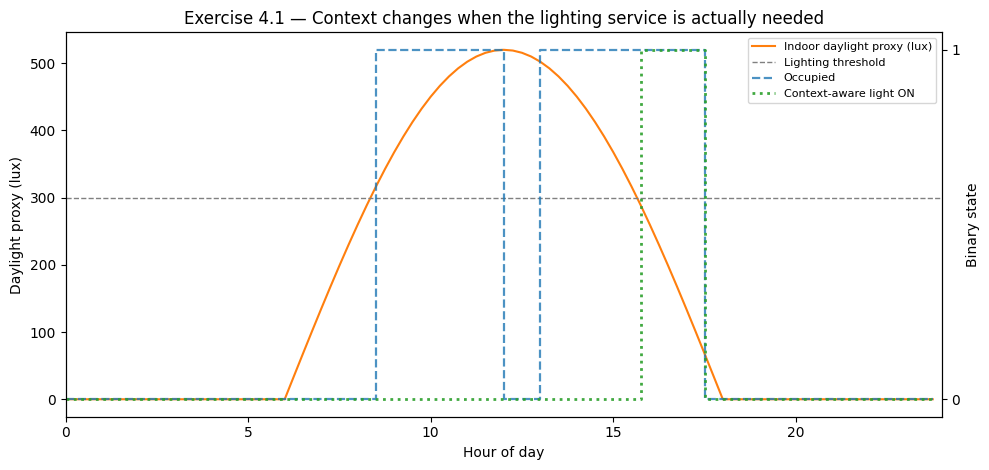

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax1.plot(hour, daylight, label='Indoor daylight proxy (lux)', color='tab:orange')
ax1.axhline(300, linestyle='--', linewidth=1, color='gray', label='Lighting threshold')
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Daylight proxy (lux)')
ax1.set_xlim(0, 24)

ax2 = ax1.twinx()
ax2.step(hour, occupied.astype(int), where='post', label='Occupied',
          linestyle='--', linewidth=1.6, alpha=0.8, color='tab:blue')
ax2.step(hour, context_light.astype(int), where='post', label='Context-aware light ON',
          linestyle=':', linewidth=2.0, alpha=0.9, color='tab:green')
ax2.set_ylabel('Binary state')
ax2.set_yticks([0, 1])

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=8)
ax1.set_title('Exercise 4.1 — Context changes when the lighting service is actually needed')
fig.tight_layout()
fig.savefig('fig_4_1_context.png', dpi=300, bbox_inches='tight')
fig.savefig('fig_4_1_context.pdf', bbox_inches='tight')
plt.show()


### Interpretation
The lighting result is intentionally large because the fixed policy ignores both vacancy and daylight. The temperature-lift proxy changes much less, which is a useful reminder: **context awareness does not guarantee the same benefit for every subsystem**.

### Challenge tasks
- Change the daylight threshold from 300 lux to 200 and 400 lux.
- Add a noisy occupancy detector: independently flip each occupancy sample with p_FP=0.05 (empty room misreported as occupied) and p_FN=0.10 (occupied room misreported as empty) using `rng = np.random.default_rng(...)`.
- Add a maximum context age: if occupancy data are older than 30 minutes, fall back to a conservative policy.
- Explain which additional metadata a real system would need: timestamp, confidence, source, room identity, and privacy policy.


## Exercise 4.2 — Cyber-physical system: why delay belongs inside the model

### Question
What happens when a physical process is controlled using **old information**?

A small room is represented by a first-order thermal model. An on/off heater attempts to keep the temperature between 21.5 °C and 22.5 °C. The controller acts on a delayed temperature observation. We compare delays of 0, 10, 30, and 60 minutes.

This is not a controller-design exercise; Chapter 12 treats control in depth. Here the purpose is to show the defining CPS idea: software timing changes physical behaviour.

In [4]:
def simulate_room(delay_min, hours=12, dt_min=1.0, tau_min=100.0, outside=10.0, heating_rate=0.13):
    n_steps = int(hours * 60 / dt_min)
    delay_steps = int(round(delay_min / dt_min))
    temperature = np.empty(n_steps + 1)
    heater = np.zeros(n_steps)
    temperature[0] = 19.0
    state = 1

    for k in range(n_steps):
        k_obs = max(0, k - delay_steps)
        measured = temperature[k_obs]
        if measured < 21.5:
            state = 1
        elif measured > 22.5:
            state = 0
        heater[k] = state
        temperature[k + 1] = temperature[k] + dt_min * (
            (outside - temperature[k]) / tau_min + heating_rate * state
        )

    # Duration accounting: temperature[:-1] holds the state at the start of
    # each of the n_steps one-minute intervals, matching heater[k]; the
    # final sample temperature[-1] is an end-of-horizon state, not the
    # start of a new interval, so it is excluded from the duration count.
    out_of_band = (temperature[:-1] < 20.5) | (temperature[:-1] > 23.0)
    violation = out_of_band.sum() * dt_min
    return temperature, heater, violation

rows = []
curves = {}
for delay in [0, 10, 30, 60]:
    T, u, violation = simulate_room(delay)
    curves[delay] = T
    rows.append({
        'Observation delay (min)': delay,
        'Comfort-band violation (min)': violation,
        'Minimum temperature (°C)': T.min(),
        'Maximum temperature (°C)': T.max(),
        'Heater duty fraction': u.mean()
    })

results_42 = pd.DataFrame(rows)
results_42


,Observation delay (min),Comfort-band violation (min),Minimum temperature (°C),Maximum temperature (°C),Heater duty fraction
0,0,47.0,19.000,22.503,0.938
1,10,68.0,19.000,22.551,0.921
2,30,209.0,18.449,22.631,0.889
3,60,240.0,16.235,22.729,0.815


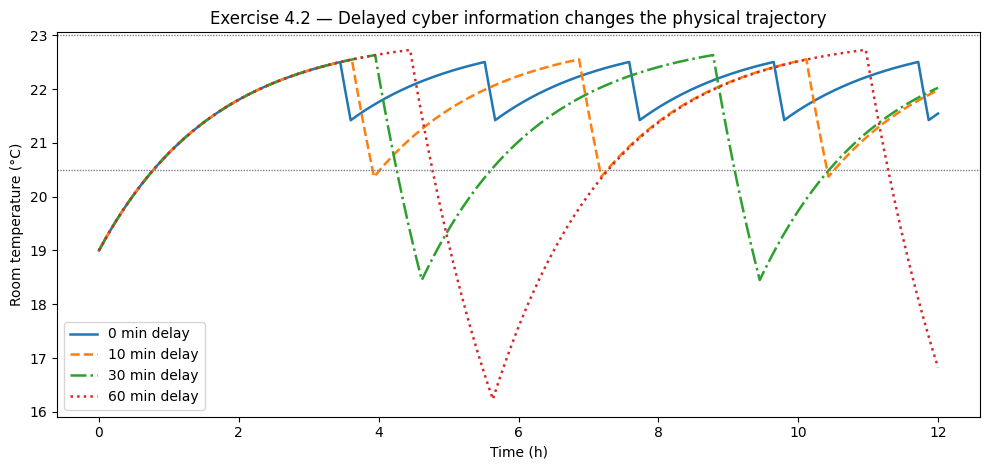

In [5]:
minutes = np.arange(len(next(iter(curves.values()))))
linestyles = ['-', '--', '-.', ':']
fig, ax = plt.subplots(figsize=(10, 4.8))
for (delay, T), ls in zip(curves.items(), linestyles):
    ax.plot(minutes / 60, T, linestyle=ls, linewidth=1.8, label=f'{delay} min delay')
ax.axhline(20.5, linestyle=(0, (1, 1)), linewidth=1, color='gray')
ax.axhline(23.0, linestyle=(0, (1, 1)), linewidth=1, color='gray')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Room temperature (°C)')
ax.set_title('Exercise 4.2 — Delayed cyber information changes the physical trajectory')
ax.legend()
fig.tight_layout()
fig.savefig('fig_4_2_cps_delay.png', dpi=300, bbox_inches='tight')
fig.savefig('fig_4_2_cps_delay.pdf', bbox_inches='tight')
plt.show()


### Interpretation
A CPS is not just a networked sensor plus software. The physical state continues to evolve while messages are delayed, queued, lost, or processed. A design that is correct with current state information can degrade when the cyber path becomes slow.

### Challenge tasks
- Define an explicit acceptance criterion first (for example, a maximum allowable comfort-band violation), then change the room time constant and determine whether the 30-minute delay remains acceptable under that criterion.
- Simulate a packet loss event by reusing the last available measurement.
- Replace the single delay with a random delay distribution.
- Define a maximum delay requirement from a chosen comfort or safety constraint.


## Exercise 4.3 — Internet of Services: composition, parallelism, and graceful degradation

### Question
If an IoT application depends on several services, how do those dependencies affect the user-visible service?

A synthetic campus ``room readiness'' request uses four services: occupancy, calendar, weather, and access status. Each service has its own availability and latency distribution. We compare three compositions:

1. **Sequential strict** — all four are required and called one after another.
2. **Parallel strict** — all four are required, but calls happen in parallel.
3. **Parallel + weather fallback** — weather is treated as optional; if unavailable, a local default is used.

The point is architectural: service boundaries hide device details, but dependencies still determine end-to-end behaviour.

In [6]:
rng = np.random.default_rng(404)
N = 20_000
services = ['occupancy', 'calendar', 'weather', 'access']
availability = np.array([0.994, 0.991, 0.982, 0.997])
median_ms = np.array([55, 70, 110, 45.0])
sigma = np.array([0.25, 0.30, 0.40, 0.20])

latency = np.empty((N, 4))
for j in range(4):
    latency[:, j] = rng.lognormal(mean=np.log(median_ms[j]), sigma=sigma[j], size=N)

ok = rng.random((N, 4)) < availability
strict_ok = ok.all(axis=1)
seq_latency = latency.sum(axis=1)
parallel_latency = latency.max(axis=1)

# Weather can be replaced by a 20-ms local fallback. The other three services remain mandatory.
gr_ok = ok[:, [0, 1, 3]].all(axis=1)
weather_component = np.where(ok[:, 2], latency[:, 2], 20.0)
gr_latency = np.maximum.reduce([latency[:, 0], latency[:, 1], latency[:, 3], weather_component])

architectures = [
    ('Sequential strict', strict_ok, seq_latency),
    ('Parallel strict', strict_ok, parallel_latency),
    ('Parallel + weather fallback', gr_ok, gr_latency),
]

rows = []
for name, success, L in architectures:
    good = L[success]
    rows.append({
        'Architecture': name,
        'Success rate (%)': 100*success.mean(),
        'Median latency (ms)': np.median(good),
        'P95 latency (ms)': np.percentile(good, 95)
    })
results_43 = pd.DataFrame(rows)
results_43

,Architecture,Success rate (%),Median latency (ms),P95 latency (ms)
0,Sequential strict,96.370,287.994,397.560
1,Parallel strict,96.370,113.570,212.717
2,Parallel + weather fallback,98.105,112.780,212.152


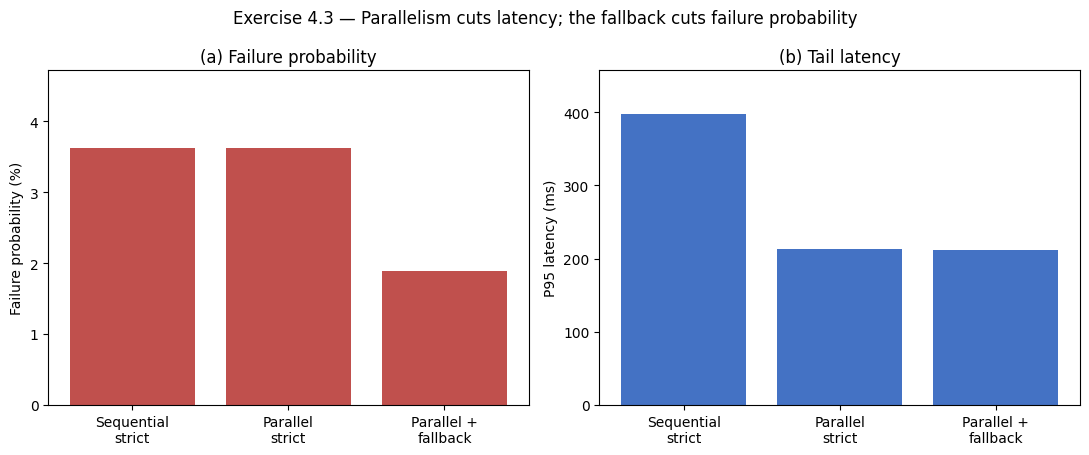

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))

labels = ['Sequential\nstrict', 'Parallel\nstrict', 'Parallel +\nfallback']
failure_pct = 100 - results_43['Success rate (%)']
p95 = results_43['P95 latency (ms)']

axes[0].bar(labels, failure_pct, color='#c0504d')
axes[0].set_ylabel('Failure probability (%)')
axes[0].set_title('(a) Failure probability')
axes[0].set_ylim(0, float(failure_pct.max()) * 1.3)

axes[1].bar(labels, p95, color='#4472c4')
axes[1].set_ylabel('P95 latency (ms)')
axes[1].set_title('(b) Tail latency')
axes[1].set_ylim(0, float(p95.max()) * 1.15)

fig.suptitle('Exercise 4.3 — Parallelism cuts latency; the fallback cuts failure probability')
fig.tight_layout()
fig.savefig('fig_4_3_services.png', dpi=300, bbox_inches='tight')
fig.savefig('fig_4_3_services.pdf', bbox_inches='tight')
plt.show()


### Interpretation
Parallelisation reduces response time without changing the probability that *all mandatory services* are available. Graceful degradation can also improve success rate, but only when the omitted/fallback information is genuinely optional. In a safety-critical function, silently replacing missing context may be unacceptable.

### Challenge tasks
- Make the access service optional and explain why that may be a bad system design.
- Add a timeout and retry policy.
- Add a fifth service and predict the strict-composition availability before running the code.
- Decide which service responses should be cached and for how long.

## Exercise 4.4 — Ambient intelligence: adaptation is a multi-objective problem

### Question
Can a smart environment adapt to people without pretending that there is one universally ``correct'' setting?

We model a shared room used by two occupants. Person A prefers 21 °C and Person B prefers 23 °C. At different times A is alone, both are present, and B is alone. The ambient system chooses a setpoint that minimises a simple objective:



$J = \text{mean squared preference discomfort} + \lambda \times \text{quadratic temperature-lift penalty}.$



The coefficient $\lambda$ is not a physical constant. It represents a design/policy choice about the weight given to resource use relative to user preference. The quadratic penalty inside $J$ is an internal optimisation term, not the same quantity as the separate, linear "temperature-lift proxy" ($^\circ$C·h) reported below for interpretability -- that proxy is computed after optimisation from the realised setpoint, in the same units and spirit as Exercise 4.1's proxy.


In [8]:
step_h = 0.25
hour = np.arange(8, 20, step_h)
preference_sets = []
for h in hour:
    if h < 12:
        preference_sets.append([21.0])
    elif h < 16:
        preference_sets.append([21.0, 23.0])
    else:
        preference_sets.append([23.0])

outside = 12.0

def evaluate_lambda(lam):
    setpoints, discomfort, person_time_discomfort, heat_proxy = [], [], [], []
    for prefs in preference_sets:
        n = len(prefs)
        # minimises sum((T-p)^2) + lam*n*(T-outside)^2
        T = (sum(prefs) + lam*n*outside) / (n*(1 + lam))
        setpoints.append(T)
        interval_mean = np.mean([(T-p)**2 for p in prefs])
        discomfort.append(interval_mean)
        # person-time weighting: each occupant-interval counted once, not
        # averaged away inside intervals with more than one occupant
        person_time_discomfort.extend([(T-p)**2 for p in prefs])
        # linear temperature-lift proxy, computed after optimisation from
        # the realised setpoint -- not the quadratic penalty inside J(T)
        heat_proxy.append(max(0, T-outside) * step_h)
    return (np.array(setpoints), np.mean(discomfort),
            np.mean(person_time_discomfort), np.sum(heat_proxy))

lambdas = [0, 0.02, 0.05, 0.10, 0.20]
rows = []
curves_44 = {}
for lam in lambdas:
    s, d, d_pt, e = evaluate_lambda(lam)
    curves_44[lam] = s
    rows.append({
        'lambda': lam,
        'Mean discomfort index': d,
        'Person-time weighted discomfort': d_pt,
        'Temperature-lift proxy (°C·h)': e,
        'Mean setpoint (°C)': s.mean()
    })

fixed_discomfort = np.mean([np.mean([(22-p)**2 for p in prefs]) for prefs in preference_sets])
fixed_discomfort_pt = np.mean([(22-p)**2 for prefs in preference_sets for p in prefs])
fixed_heat_proxy = (22-outside) * (len(hour)*step_h)

results_44 = pd.DataFrame(rows)
print('Fixed 22 °C baseline — interval-weighted discomfort:', round(fixed_discomfort, 3),
      '| person-time weighted:', round(fixed_discomfort_pt, 3),
      '| temperature-lift proxy:', round(fixed_heat_proxy, 1))
results_44


Fixed 22 °C baseline — interval-weighted discomfort: 1.0 | person-time weighted: 1.0 | temperature-lift proxy: 120.0


,lambda,Mean discomfort index,Person-time weighted discomfort,Temperature-lift proxy (°C·h),Mean setpoint (°C)
0,0.00,0.333,0.500,120.000,22.000
1,0.02,0.372,0.539,117.647,21.804
2,0.05,0.562,0.728,114.286,21.524
3,0.10,1.165,1.331,109.091,21.091
4,0.20,3.130,3.292,100.000,20.333


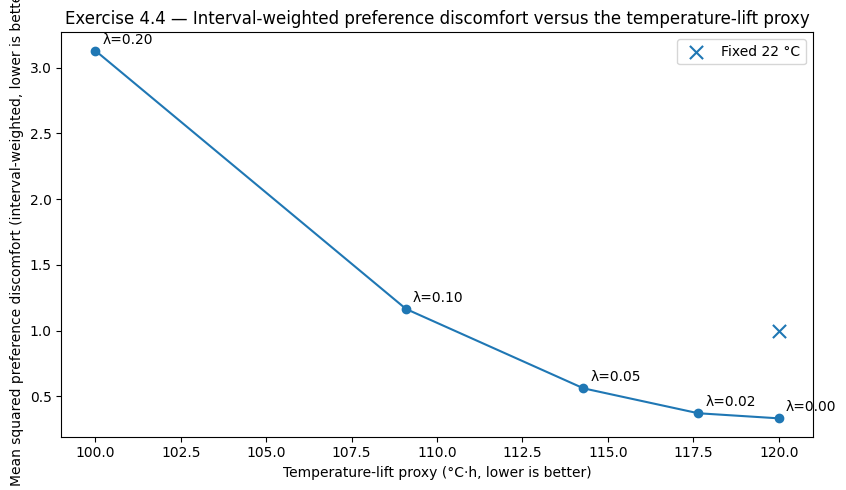

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 5.0))
col = 'Temperature-lift proxy (°C·h)'
ax.plot(results_44[col], results_44['Mean discomfort index'], marker='o')
for _, r in results_44.iterrows():
    ax.annotate(f"λ={r['lambda']:.2f}", (r[col], r['Mean discomfort index']), xytext=(5,5), textcoords='offset points')
ax.scatter([fixed_heat_proxy], [fixed_discomfort], marker='x', s=90, label='Fixed 22 °C')
ax.set_xlabel('Temperature-lift proxy (°C·h, lower is better)')
ax.set_ylabel('Mean squared preference discomfort (interval-weighted, lower is better)')
ax.set_title('Exercise 4.4 — Interval-weighted preference discomfort versus the temperature-lift proxy')
ax.legend()
fig.tight_layout()
fig.savefig('fig_4_4_ambient.png', dpi=300, bbox_inches='tight')
fig.savefig('fig_4_4_ambient.pdf', bbox_inches='tight')
plt.show()


### Interpretation
The important lesson is not the numerical optimum. A genuinely human-centred ambient system must decide **whose preferences count, how strongly, when adaptation is allowed, and what happens when preferences conflict**. The optimisation objective therefore contains policy choices, not just technical parameters.

The discomfort metric itself is one such choice. Averaging equally over 15-minute intervals gives an hour with two occupants the same aggregate weight as an hour with one occupant; averaging equally over person-time instead gives the two-occupant hour twice the weight. Both are legitimate conventions, and the table above reports both so the difference is visible rather than hidden inside a single number.

### Challenge tasks
- Give one occupant twice the weight of the other and discuss whether the policy is justified.
- Add a maximum allowed setpoint change per hour to avoid abrupt adaptation.
- Introduce a third occupant and compare majority, average-preference, and fairness-oriented policies.
- Compare the interval-weighted and person-time weighted discomfort curves across all five λ values, and explain when each convention is the more appropriate design choice.
- List the privacy information the system would need to store to personalise the room.


## Practice summary

These four experiments form one conceptual chain:

- **Context awareness** determines which facts influence behaviour.
- **CPS reasoning** reminds us that sensing, computation, communication, and physical dynamics happen in time.
- **Internet of Services** abstracts capabilities but introduces dependency and composition effects.
- **Ambient intelligence** combines pervasive sensing and context-aware adaptation with explicitly human-centred goals.

The later chapters of the book turn these ideas into concrete device, gateway, platform, sensing, control, data-acquisition, and communication designs.